<a href="https://colab.research.google.com/github/adrianIT96/Premier-League-ML/blob/main/A_Multi_Season_Linear_Regression_Analysisd0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Premier League Performance Analysis
Using Multiple Linear Regression to predict season points based on Expected Goals (xG), xG Allowed (xGA), and Squad Value.


In [ ]:
import pandas as pd
import io
import re
from google.colab import files

# 1. Upload prompt
print("Select and upload your 5 CSV files (20/21, 21/22, 22/23, 23/24, 24/25):")
uploaded = files.upload()

# 2. Helper function to clean Squad Value strings
def clean_currency(value):
    if isinstance(value, str):
        # Remove Euro symbols and other non-numeric chars, keep 'm' and 'bn'
        clean_val = re.sub(r'[^\d.mbn]', '', value.lower())
        if 'bn' in clean_val:
            return float(clean_val.replace('bn', '')) * 1000
        if 'm' in clean_val:
            return float(clean_val.replace('m', ''))
        try:
            return float(clean_val)
        except:
            return 0.0
    return float(value)

# 3. Processing and merging
all_seasons_list = []

for file_name in uploaded.keys():
    # Load each file
    df_temp = pd.read_csv(io.BytesIO(uploaded[file_name]), sep=None, engine='python', encoding='latin1')

    # Standardize column names (remove possible spaces)
    df_temp.columns = df_temp.columns.str.strip()

    # Clean 'Squad Value' if it exists
    if 'Squad Value' in df_temp.columns:
        df_temp['Squad Value'] = df_temp['Squad Value'].apply(clean_currency)

    # Add a column to keep track of which file the data came from
    df_temp['Source_File'] = file_name

    all_seasons_list.append(df_temp)

# Combine everything into one big DataFrame
df_total = pd.concat(all_seasons_list, ignore_index=True)

# Final check
print("\n--- Data successfully merged! ---")
print(f"Total rows (teams): {len(df_total)}")
print("\nFirst 5 rows of the merged table:")
print(df_total[['Team Name', 'xG', 'xGA', 'Squad Value', 'PTS']].head())

Select and upload your 5 CSV files (20/21, 21/22, 22/23, 23/24, 24/25):


Saving pl_20.csv to pl_20 (2).csv
Saving pl_21.csv to pl_21 (2).csv
Saving pl_22.csv to pl_22 (2).csv
Saving pl_23.csv to pl_23 (2).csv
Saving pl_24.csv to pl_24 (2).csv

--- Data successfully merged! ---
Total rows (teams): 100

First 5 rows of the merged table:
           Team Name     xG    xGA  Squad Value  PTS
0    Manchester City  77.72  30.61       1040.0   86
1  Manchester United  63.17  41.92        770.1   74
2          Liverpool  72.21  47.30        969.7   69
3            Chelsea  68.66  30.90        889.2   67
4          Leicester  58.80  47.07        510.6   66


### Feature Engineering: Z-score Normalization

To ensure Gradient Descent converges efficiently, we scale our features (xG, xGA, Squad Value) to have a mean of 0 and a standard deviation of 1.

Iteration    0: Cost  1230.77
Iteration  100: Cost    24.74
Iteration  200: Cost    24.72
Iteration  300: Cost    24.72
Iteration  400: Cost    24.72
Iteration  500: Cost    24.72
Iteration  600: Cost    24.72
Iteration  700: Cost    24.72
Iteration  800: Cost    24.72
Iteration  900: Cost    24.72
Iteration 1000: Cost    24.72
Iteration 1100: Cost    24.72
Iteration 1200: Cost    24.72
Iteration 1300: Cost    24.72
Iteration 1400: Cost    24.72

TRAINING FINISHED
Final Weights: xG: 8.40, xGA: -6.59, Squad Value: 3.93
Final Bias (b): 52.67
Mean Absolute Error (MAE): 5.54 points


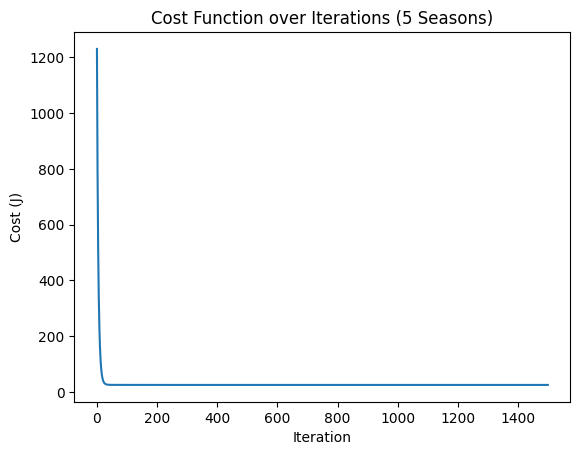

In [ ]:
# --- STEP 1: PREPARE DATA ---
# Select our features (X) and target (y)
features = ['xG', 'xGA', 'Squad Value']
X_raw = df_total[features].values
y_train = df_total['PTS'].values

# Feature Scaling (Z-score Normalization)
def zscore_normalize_features(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

X_train, mu, sigma = zscore_normalize_features(X_raw)

# --- STEP 2: MULTIPLE LINEAR REGRESSION FUNCTIONS ---
def compute_cost(X, y, w, b):
    m = X.shape[0]
    predictions = np.dot(X, w) + b
    cost = np.sum((predictions - y)**2) / (2 * m)
    return cost

def compute_gradient(X, y, w, b):
    m, n = X.shape
    predictions = np.dot(X, w) + b
    err = predictions - y
    dj_dw = np.dot(X.T, err) / m
    dj_db = np.sum(err) / m
    return dj_dw, dj_db

def gradient_descent(X, y, w_in, b_in, alpha, num_iters):
    w = w_in
    b = b_in
    J_history = []

    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient(X, y, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        J_history.append(compute_cost(X, y, w, b))

        if i % 100 == 0:
            print(f"Iteration {i:4d}: Cost {J_history[-1]:8.2f}")

    return w, b, J_history

# --- STEP 3: RUN TRAINING ---
initial_w = np.zeros(X_train.shape[1])
initial_b = 0.
iterations = 1500
alpha = 0.1

w_final, b_final, J_hist = gradient_descent(X_train, y_train, initial_w, initial_b, alpha, iterations)

# --- STEP 4: FINAL METRICS ---
df_total['Predicted_PTS'] = np.dot(X_train, w_final) + b_final
df_total['Abs_Error'] = np.abs(df_total['Predicted_PTS'] - df_total['PTS'])
mae = df_total['Abs_Error'].mean()

print("\n" + "="*30)
print("TRAINING FINISHED")
print(f"Final Weights: xG: {w_final[0]:.2f}, xGA: {w_final[1]:.2f}, Squad Value: {w_final[2]:.2f}")
print(f"Final Bias (b): {b_final:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f} points")
print("="*30)

# Plotting the Cost Function
plt.plot(J_hist)
plt.title("Cost Function over Iterations (5 Seasons)")
plt.xlabel("Iteration")
plt.ylabel("Cost (J)")
plt.show()

### Machine Learning Model
I implemented Gradient Descent from scratch to optimize our weights. The goal is to minimize the Cost Function (Mean Squared Error).

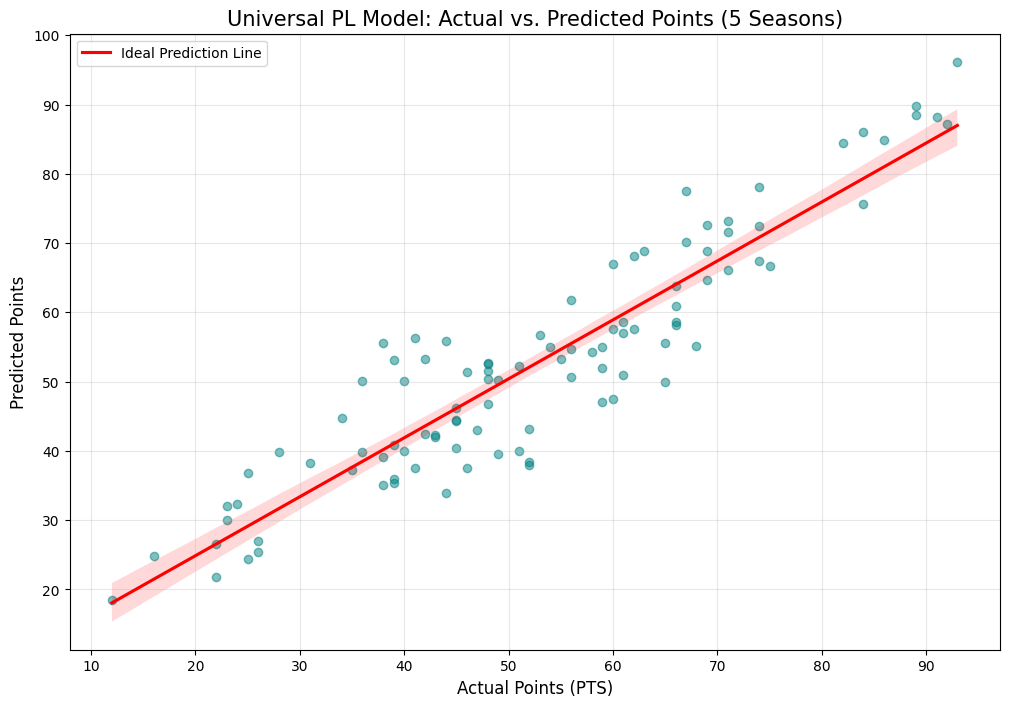


Top 3 Seasons where teams most 'Overperformed' the model:
            Team Name  PTS  Predicted_PTS   Residual
86  Nottingham Forest   65      49.903401  15.096599
49             Fulham   52      37.937092  14.062908
68           West Ham   52      38.336213  13.663787


In [ ]:
import seaborn as sns

plt.figure(figsize=(12, 8))

# Create a scatter plot of Actual vs Predicted
sns.regplot(data=df_total, x='PTS', y='Predicted_PTS',
            scatter_kws={'alpha':0.5, 'color':'teal'},
            line_kws={'color':'red', 'label':'Ideal Prediction Line'})

plt.title('Universal PL Model: Actual vs. Predicted Points (5 Seasons)', fontsize=15)
plt.xlabel('Actual Points (PTS)', fontsize=12)
plt.ylabel('Predicted Points', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Quick summary of the biggest overperformers/underperformers
df_total['Residual'] = df_total['PTS'] - df_total['Predicted_PTS']
print("\nTop 3 Seasons where teams most 'Overperformed' the model:")
print(df_total.sort_values(by='Residual', ascending=False)[['Team Name', 'PTS', 'Predicted_PTS', 'Residual']].head(3))


### Results and Visualization
The 3D surface plot illustrates the "Bowl" of our Cost Function, with the red marker pinpointing the optimized parameters found by the model.

In [15]:
# Tento riadok zapne interaktívne grafy v Google Colab
%matplotlib inline
import plotly.graph_objects as go

def plot_3d_bowl_interactive(X, y, w_final, b_final):
    # 1. Grid setup
    w_range = np.linspace(w_final[0] - 15, w_final[0] + 15, 50)
    b_range = np.linspace(b_final - 30, b_final + 30, 50)
    W, B = np.meshgrid(w_range, b_range)
    Z = np.zeros(W.shape)

    # 2. Cost calculation
    for i in range(W.shape[0]):
        for j in range(W.shape[1]):
            tmp_w = np.array([W[i,j], w_final[1], w_final[2]])
            Z[i,j] = compute_cost(X, y, tmp_w, B[i,j])

    # 3. Plotting with Plotly (Umožňuje plynulé otáčanie v prehliadači)
    fig = go.Figure(data=[
        go.Surface(x=W, y=B, z=Z, colorscale='Viridis', opacity=0.8),
        go.Scatter3d(
            x=[w_final[0]], y=[b_final], z=[compute_cost(X, y, w_final, b_final)],
            mode='markers',
            marker=dict(size=10, color='red', symbol='circle', line=dict(width=2, color='white')),
            name='Optimized Solution'
        )
    ])

    fig.update_layout(
        title='Interactive Cost Function Surface',
        scene=dict(
            xaxis_title='Weight (xG)',
            yaxis_title='Bias (b)',
            zaxis_title='Cost (J)'
        ),
        margin=dict(l=0, r=0, b=0, t=40)
    )
    fig.show()

# Run the interactive plot
plot_3d_bowl_interactive(X_train, y_train, w_final, b_final)